## Data Ingestion and Preparation

In [11]:
import pandas as pd
df = pd.read_csv("/content/airline_passengers_cleaned.csv")
df.head(10)

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0
5,1949-06-01,135.0
6,1949-07-01,148.0
7,1949-08-01,148.0
8,1949-09-01,136.0
9,1949-10-01,119.0


In [12]:
df.tail(10)

,Month,Thousands of Passengers
134,1960-03-01,419.0
135,1960-04-01,461.0
136,1960-05-01,472.0
137,1960-06-01,535.0
138,1960-07-01,622.0
139,1960-08-01,606.0
140,1960-09-01,508.0
141,1960-10-01,461.0
142,1960-11-01,390.0
143,1960-12-01,432.0


In [13]:
df.count()

,0
Month,144
Thousands of Passengers,144


* Monthly totals of international airline passengers

* Time range: Jan 1949 → Dec 1960

* Total points: 144

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    144 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


1. No null values in any columns
2. `Month` column needs to be in `datetime` object


In [15]:
df['Month'] = pd.to_datetime(df['Month'])

In [16]:
df.head()

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [17]:
df.set_index('Month', inplace=True)

## Data Cleaning

In [23]:
# checking frequency
pd.infer_freq(df.index)

'MS'

>  the frequency of your DataFrame's index as 'MS', which stands for Month Start frequency. This means your data points are recorded at the beginning of each month.


In [27]:
# Checking if our data is regular and not randomly logged

# Create a complete date range for the observed period at 'MS' frequency
start_date = df.index.min()
end_date = df.index.max()
full_date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Find dates that are in the full range but not in the DataFrame's index
missing_dates = full_date_range.difference(df.index)
# returns all elements that are in the first set (full_date_range) but not in the second set (df.index).


if not missing_dates.empty:
    print(f"There are {len(missing_dates)} missing dates/months in the time series:")
    for date in missing_dates:
        print(date.strftime('%Y-%m'))
else:
    print("The time series index is complete with no missing months.")


The time series index is complete with no missing months.


> data is already complete and regular, and these checks confirm it.

In [28]:
# since we have no null values, no imputation or interpolation needed!

## EDA & Visualization

Series Decomposition

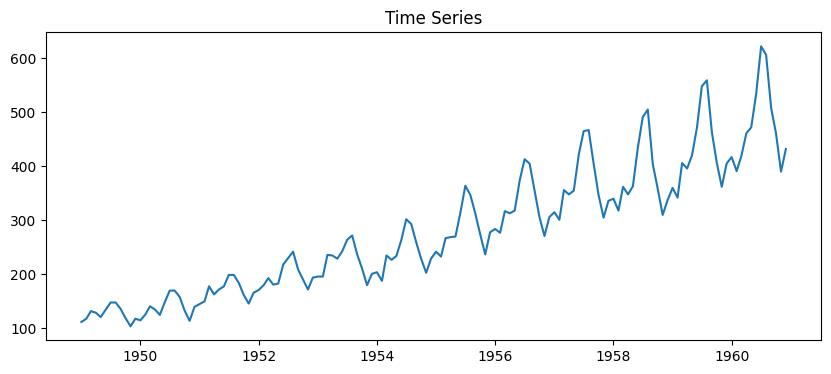

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df['Thousands of Passengers'], label='Passengers')
plt.title("Time Series")
plt.show()

* There is a clear upward trend.
* Strong seasonality, number of passengers peak in july/august each year.
* Increasing variance and mean is not constant.
* No sharp drop or spikes out of the box
* multiplicative model


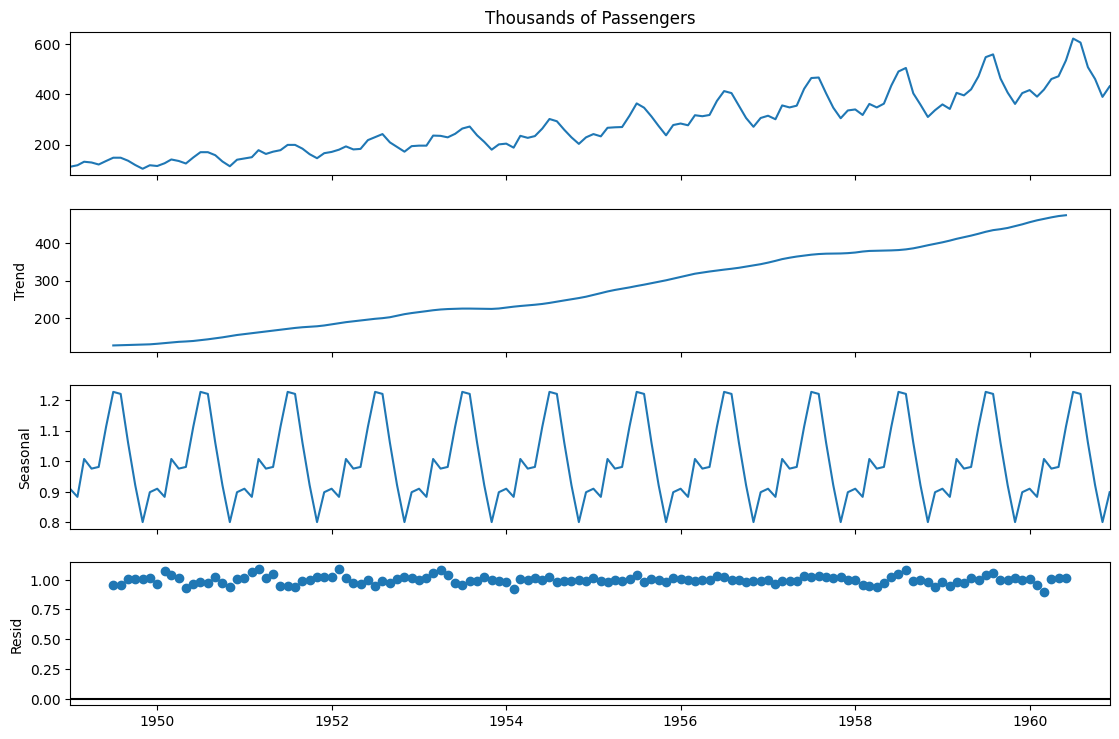

In [34]:
# Plotting decomposed components

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['Thousands of Passengers'], model='multiplicative',
    period=12                 # has yearly seasonality
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

* long-term upward movement in passenger numbers
* obvious seasonality - amplitude of the seasonal component itself, after the trend has been factored out, appears more stable. It consistently shows the same pattern of highs and lows relative to the trend, year after year.

Checking for stationarity

In [37]:
from statsmodels.tsa.stattools import adfuller

# ADF test
def adf_test(series):
    """Using an ADF test to determine if a series is stationary"""
    test_results = adfuller(series)
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %.2f' % (thres, adf_stat))

adf_test(df['Thousands of Passengers'])

ADF Statistic:  0.8153688792060498
P-Value:  0.991880243437641
Critical Values:
	1%: -3.48
	5%: -2.88
	10%: -2.58


> Since the p-value is way larger than the standard 5% critical value, therefore our data is clearly *Non Stationary, and has a trend* which we had already visualized!!

## Data Preprocessing

In [38]:
# the best transformation is to use log or boxcox

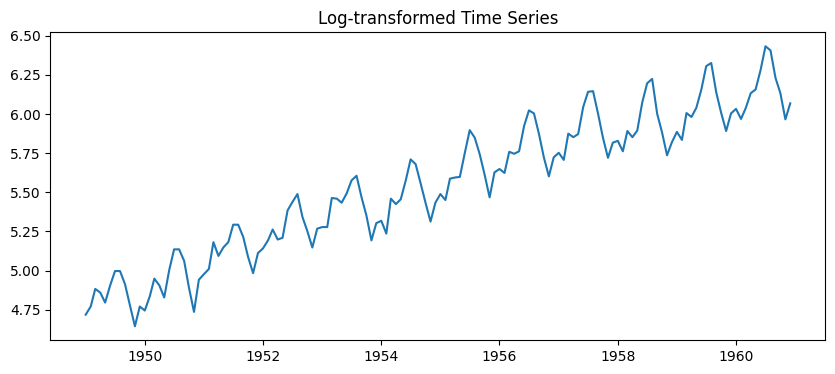

In [39]:
import numpy as np

df['Passengers_Log'] = np.log(df['Thousands of Passengers'])

plt.figure(figsize=(10,4))
plt.plot(df['Passengers_Log'], label='Log-transformed Passengers')
plt.title('Log-transformed Time Series')
plt.show()


> visually `variance` looks balanced now overall, while the `mean` still varies.

In [40]:
# Now, let's re-run the Augmented Dickey-Fuller (ADF) test on the log-transformed series to see if the transformation has helped in achieving stationarity.
adf_test(df['Passengers_Log'])

ADF Statistic:  -1.7170170891069683
P-Value:  0.4223667747703874
Critical Values:
	1%: -3.48
	5%: -2.88
	10%: -2.58


> Since our p-value (0.422) is still much larger than the typical significance levels (e.g., 0.05 or 0.10), we cannot reject the null hypothesis. This means that, even after the log transformation, we still do not have sufficient evidence to conclude that the series is stationary. The ADF Statistic (-1.717) is also not less than any of the critical values.

> While the log transformation helped to stabilize the variance, the series still appears to have a trend component, meaning it is still non-stationary. This indicates that further differencing will likely be needed to achieve stationarity.

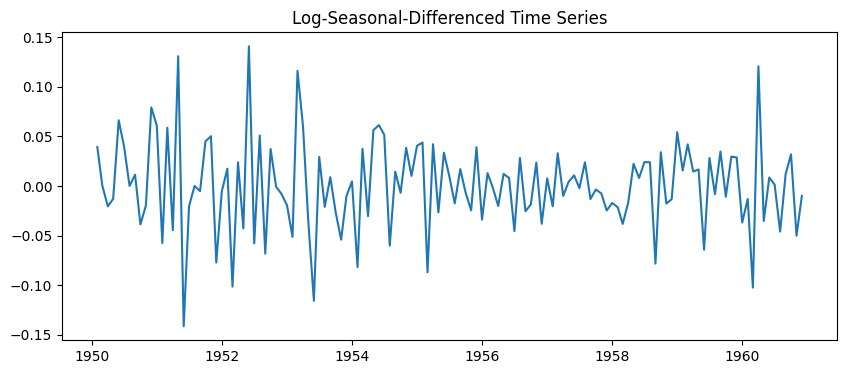

In [41]:
# for stationarity of mean, applying diffrencing
# First-order differencing
df['Passengers_Log_Diff'] = df['Passengers_Log'].diff()

# Seasonal differencing (period = 12 for monthly data)
df['Passengers_Log_Seasonal_Diff'] = df['Passengers_Log_Diff'].diff(12)

# Drop NaN values resulting from differencing
df_differenced = df.dropna(subset=['Passengers_Log_Seasonal_Diff'])

plt.figure(figsize=(10,4))
plt.plot(df_differenced['Passengers_Log_Seasonal_Diff'], label='Log-Seasonal-Differenced Passengers')
plt.title('Log-Seasonal-Differenced Time Series')
plt.show()


* the mean of this series now appears to be constant and centered around zero.
* luctuations (variance) also appear much more consistent across the entire series.
* The seasonal differencing has effectively removed the yearly seasonality.
* **The series now looks much more like 'white noise' or a random process, which is the visual hallmark of a stationary time series.**

In [42]:
# Now, let's run the ADF test on the new double-differenced series (`Passengers_Log_Seasonal_Diff`) to confirm stationarity.
adf_test(df_differenced['Passengers_Log_Seasonal_Diff'])

ADF Statistic:  -4.4433249418311425
P-Value:  0.00024859123113838495
Critical Values:
	1%: -3.49
	5%: -2.89
	10%: -2.58


> the P-value is now much smaller than the standard critical values, therefore stationary.

Now that we have successfully achieved stationarity, the next steps involve preparing for and performing time series forecasting.

* Split Data into Training and Testing Sets: Divide the stationary time series data chronologically into training and testing sets. A common split would be to use the first 80% for training and the last 20% for testing, or a specific number of last months for testing.

In [47]:
train = df_differenced['Passengers_Log_Seasonal_Diff'][:'1959']
test = df_differenced['Passengers_Log_Seasonal_Diff']['1960':]

In [48]:
train.shape

(119,)

In [49]:
test.shape

(12,)

Choosing model orders for training SARIMA

In [52]:
!pip install pmdarima
import pmdarima as pm

model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True
)
model.summary()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.9 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=-433.877, Time=1.37 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-397.154, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-431.934, Time=0.32 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-439.244, Time=0.36 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-399.051, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=-408.041, Time=0.08 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=-437.461, Time=0.65 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=-437.490, Time=0.92 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=-432.791, Time=0.27 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=-435.439, Time=1.42 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=-428.255, Time=1.49 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=-437.517, Time=1.33 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=-437.305, Time=0.46 sec
 ARIMA

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  119
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood                 223.627
Date:                            Mon, 17 Nov 2025   AIC                           -441.253
Time:                                    17:13:22   BIC                           -432.916
Sample:                                02-01-1950   HQIC                          -437.868
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3484      0.081     -4.301      0.000      -0.507      -0.190
ma.S.L12      -0.5623      0.094     -5.956      0.000      -0.747      -0.377
sigma2         0.0013      0.000      8.496      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.15
Prob(Q):                              0.93   Prob(JB):                         0.56
Heteroskedasticity (H):               0.38   Skew:                             0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [53]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train,
                order=(0,0,1),
                seasonal_order=(0,0,1,12))
model_fit = model.fit()
model_fit.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:       Passengers_Log_Seasonal_Diff   No. Observations:                  119
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood                 223.627
Date:                            Mon, 17 Nov 2025   AIC                           -441.253
Time:                                    17:14:39   BIC                           -432.916
Sample:                                02-01-1950   HQIC                          -437.868
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3484      0.081     -4.301      0.000      -0.507      -0.190
ma.S.L12      -0.5623      0.094     -5.956      0.000      -0.747      -0.377
sigma2         0.0013      0.000      8.496      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.15
Prob(Q):                              0.93   Prob(JB):                         0.56
Heteroskedasticity (H):               0.38   Skew:                             0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Making predictions

In [54]:
pred = model_fit.predict(start=test.index[0],
                         end=test.index[-1])


In [55]:
# visualizing

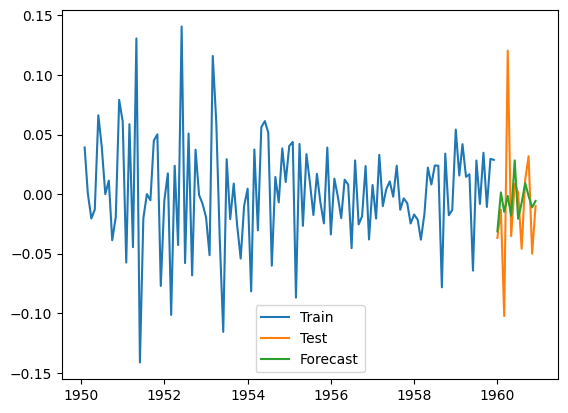

In [56]:
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(pred, label='Forecast')
plt.legend()


Evaluation


In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse = mean_squared_error(test, pred)
mae  = mean_absolute_error(test, pred)
mape = mean_absolute_percentage_error(test, pred)
print(rmse, mae, mape)


0.002341723121951195 0.03387542427257568 2.1044080400671956


### Data Analysis Key Findings

*   **RMSE (Root Mean Squared Error) of 0.00234:** This value indicates that, on average, the model's predictions for the `Passengers_Log_Seasonal_Diff` series are very close to the actual values.

*   **MAE (Mean Absolute Error) of 0.0339:** This means that, on average, the model's predictions for the `Passengers_Log_Seasonal_Diff` series deviate by approximately 0.0339 units from the actual values. This relatively small MAE further confirms strong predictive performance on the stationary data.

*   **MAPE (Mean Absolute Percentage Error) of 2.104\%:** This low percentage implies that the forecast is, on average, off by only about 2.104\% relative to the actual `differenced log passenger counts`.

# Task
Modify the inverse transformation code to use `cumsum()` for the inverse first-order differencing step, then confirm the updated inverse transformation logic and the resulting forecasts.

## Modify Inverse Transformation with cumsum()

### Subtask:
Modify the inverse transformation code to use `cumsum()` for the inverse first-order differencing step, making it more concise and idiomatic.


**Reasoning**:
To perform the inverse transformations, I will implement the steps outlined in the subtask. This involves inverse seasonal differencing, inverse first-order differencing using `cumsum()`, and inverse log transformation to get the forecasts back to the original scale.



In [60]:
import numpy as np

# 2a. Extract Passengers_Log_Diff for the 12 months preceding the test period
prev_year_log_diff_values = df['Passengers_Log_Diff']['1959-01-01':'1959-12-01']

# 2b. Create a new pandas Series from prev_year_log_diff_values, using test.index
aligned_prev_year_log_diff = pd.Series(prev_year_log_diff_values.values, index=test.index)

# 2c. Add pred to aligned_prev_year_log_diff to obtain forecast_log_diff
forecast_log_diff = pred + aligned_prev_year_log_diff

# 3a. Retrieve the last actual Passengers_Log value in the training period
last_log_value_in_train = df['Passengers_Log'].loc['1959-12-01']

# 3b. Apply cumsum() and add last_log_value_in_train
forecast_log = last_log_value_in_train + forecast_log_diff.cumsum()

# 4a. Apply np.exp() to transform back to original scale
forecast_original = np.exp(forecast_log)

print("Original scale forecast head:")
print(forecast_original.head())
print("\nOriginal scale forecast tail:")
print(forecast_original.tail())

Original scale forecast head:
1960-01-01    419.325138
1960-02-01    398.920877
1960-03-01    466.579123
1960-04-01    454.407026
1960-05-01    473.263050
Freq: MS, dtype: float64

Original scale forecast tail:
1960-08-01    630.149508
1960-09-01    526.746304
1960-10-01    462.289591
1960-11-01    406.627650
1960-12-01    452.296251
Freq: MS, dtype: float64


## Since the model is ready, and works fine.. it's time to **.fit()** model with these parameters on the **WHOLE DATASET** and the **forecast** for the next  12/24 months

In [62]:
df_differenced.head()

,Thousands of Passengers,Passengers_Log,Passengers_Log_Diff,Passengers_Log_Seasonal_Diff
Month,,,,
1950-02-01,126.0,4.836282,0.091350,0.039164
1950-03-01,141.0,4.948760,0.112478,0.000361
1950-04-01,135.0,4.905275,-0.043485,-0.020496
1950-05-01,125.0,4.828314,-0.076961,-0.012939
1950-06-01,149.0,5.003946,0.175633,0.066148


taking only the `Passengers_Log_Seasonal_Diff` because it is stationary

In [63]:
y_full = df_differenced["Passengers_Log_Seasonal_Diff"].dropna()

final_model = SARIMAX(y_full, order=(0,0,1), seasonal_order=(0,0,1,12)).fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



### Forecasting for next 12 months

In [64]:
mnths = 12
forecast_diff = final_model.forecast(mnths)
forecast_diff


,predicted_mean
1961-01-01,0.012561
1961-02-01,0.007968
1961-03-01,0.048776
1961-04-01,-0.067942
1961-05-01,0.009675
1961-06-01,0.010935
1961-07-01,-0.012158
1961-08-01,0.021673
1961-09-01,-0.001810
1961-10-01,-0.018607


In [67]:
plt.figure(figsize=(14,6))

# Train
plt.plot(train.index, train['Passengers_Log_Seasonal_Diff'], label='Train')

# Test (True)
plt.plot(test.index, test['Passengers_Log_Seasonal_Diff'], label='Test (True)')

# Test (Predicted)
plt.plot(test.index, pred, label='Test (Predicted)')

# Future Forecast (Predicted)
last_date = df_differenced.index[-1]
future_dates = pd.date_range(start=last_date, periods=13, freq='MS')[1:]

plt.plot(future_dates, forecast_diff, label='Future Forecast (Diff Scale)', marker='o')

plt.title("Differenced Scale Forecast: Train | Test | Next 12 Months")
plt.legend()
plt.show()


KeyError: 'Passengers_Log_Seasonal_Diff'

<Figure size 1400x600 with 0 Axes>

In [66]:
train

,Passengers_Log_Seasonal_Diff
Month,
1950-02-01,0.039164
1950-03-01,0.000361
1950-04-01,-0.020496
1950-05-01,-0.012939
1950-06-01,0.066148
...,...
1959-08-01,-0.008240
1959-09-01,0.034721
1959-10-01,-0.010821


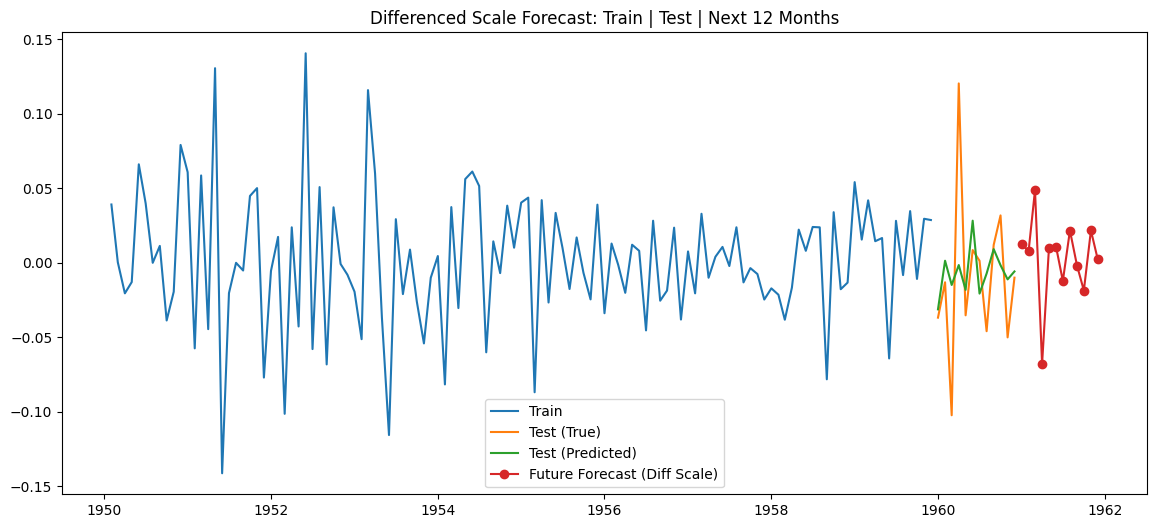

In [69]:
plt.figure(figsize=(14,6))

# Train
plt.plot(train.index, train, label='Train')

# Test (True)
plt.plot(test.index, test, label='Test (True)')

# Test (Predicted)
plt.plot(test.index, pred, label='Test (Predicted)')

# Future Forecast (Predicted)
last_date = df_differenced.index[-1]
future_dates = pd.date_range(start=last_date, periods=13, freq='MS')[1:]

plt.plot(future_dates, forecast_diff, label='Future Forecast (Diff Scale)', marker='o')

plt.title("Differenced Scale Forecast: Train | Test | Next 12 Months")
plt.legend()
plt.show()

---
# **Autocompleted rest**

Inversing all transformations to ORIGINAL SCALE


# Task
```python
import numpy as np

# 1. Inverse Seasonal Differencing
# The forecast_diff is for 1961-01-01 to 1961-12-01
# We need Passengers_Log_Diff from 1960-01-01 to 1960-12-01
prev_year_log_diff_values_for_forecast = df['Passengers_Log_Diff']['1960-01-01':'1960-12-01']

# Create a new pandas Series from prev_year_log_diff_values_for_forecast,
# using the index of forecast_diff
aligned_prev_year_log_diff_for_forecast = pd.Series(
    prev_year_log_diff_values_for_forecast.values, index=forecast_diff.index
)

# Add forecast_diff to aligned_prev_year_log_diff_for_forecast to obtain forecast_log_diff
forecast_log_diff_restored = forecast_diff + aligned_prev_year_log_diff_for_forecast

# 2. Inverse First-Order Differencing
# Retrieve the last actual Passengers_Log value before the forecast period
last_log_value_before_forecast = df['Passengers_Log'].loc['1960-12-01']

# Apply cumsum() and add last_log_value_before_forecast
forecast_log_restored = last_log_value_before_forecast + forecast_log_diff_restored.cumsum()

# 3. Inverse Log Transformation
# Apply np.exp() to transform back to original scale
final_forecast_original_scale = np.exp(forecast_log_restored)

print("Final forecast in original scale (head):")
print(final_forecast_original_scale.head())
print("\nFinal forecast in original scale (tail):")
print(final_forecast_original_scale.tail())
```

## Inverse Seasonal Differencing

### Subtask:
Apply the inverse seasonal differencing to `forecast_diff`. This involves adding the `Passengers_Log_Diff` values from the previous year to the `forecast_diff` series to reconstruct the `forecast_log_diff`.


**Reasoning**:
The subtask requires performing inverse seasonal differencing. This first step extracts the `Passengers_Log_Diff` values from the year 1960, which corresponds to the previous year relative to the forecasted period (1961), as required for seasonal differencing inversion.



In [70]:
prev_year_log_diff_values_for_forecast = df['Passengers_Log_Diff']['1960-01-01':'1960-12-01']
print(prev_year_log_diff_values_for_forecast.head())

Month
1960-01-01    0.029199
1960-02-01   -0.064379
1960-03-01    0.069163
1960-04-01    0.095527
1960-05-01    0.023581
Name: Passengers_Log_Diff, dtype: float64


**Reasoning**:
To perform inverse seasonal differencing, I need to align the `prev_year_log_diff_values_for_forecast` with the index of `forecast_diff`.



In [71]:
aligned_prev_year_log_diff_for_forecast = pd.Series(
    prev_year_log_diff_values_for_forecast.values, index=forecast_diff.index
)
print(aligned_prev_year_log_diff_for_forecast.head())

1961-01-01    0.029199
1961-02-01   -0.064379
1961-03-01    0.069163
1961-04-01    0.095527
1961-05-01    0.023581
Freq: MS, dtype: float64


**Reasoning**:
Now that the `prev_year_log_diff_values_for_forecast` are aligned with the `forecast_diff` index, I will add these two series to perform the inverse seasonal differencing, as per the subtask instructions.



In [72]:
forecast_log_diff_restored = forecast_diff + aligned_prev_year_log_diff_for_forecast
print(forecast_log_diff_restored.head())

1961-01-01    0.041760
1961-02-01   -0.056410
1961-03-01    0.117940
1961-04-01    0.027585
1961-05-01    0.033255
Freq: MS, dtype: float64


**Reasoning**:
Now that inverse seasonal differencing is complete, I will proceed with inverse first-order differencing. This requires retrieving the last actual `Passengers_Log` value from the original `df` before the forecast period to serve as the starting point for the cumulative sum.



In [73]:
last_log_value_before_forecast = df['Passengers_Log'].loc['1960-12-01']
print(f"Last Passengers_Log value before forecast: {last_log_value_before_forecast}")

Last Passengers_Log value before forecast: 6.068425588244111


**Reasoning**:
With the inverse seasonal differencing applied and the last log value obtained, I will now perform inverse first-order differencing using `cumsum()` on `forecast_log_diff_restored` and add `last_log_value_before_forecast` to obtain the log-transformed forecast, as specified in the subtask.



In [74]:
forecast_log_restored = last_log_value_before_forecast + forecast_log_diff_restored.cumsum()
print("Log-transformed forecast (head):")
print(forecast_log_restored.head())

Log-transformed forecast (head):
1961-01-01    6.110185
1961-02-01    6.053775
1961-03-01    6.171715
1961-04-01    6.199300
1961-05-01    6.232556
Freq: MS, dtype: float64


**Reasoning**:
With the log-transformed forecast restored, the final step is to apply the inverse log transformation using `np.exp()` to convert the `forecast_log_restored` back to the original scale (thousands of passengers).



In [75]:
final_forecast_original_scale = np.exp(forecast_log_restored)

print("Final forecast in original scale (head):")
print(final_forecast_original_scale.head())
print("\nFinal forecast in original scale (tail):");
print(final_forecast_original_scale.tail())

Final forecast in original scale (head):
1961-01-01    450.422182
1961-02-01    425.717051
1961-03-01    479.006749
1961-04-01    492.404242
1961-05-01    509.054715
Freq: MS, dtype: float64

Final forecast in original scale (tail):
1961-08-01    667.077300
1961-09-01    558.189125
1961-10-01    497.207544
1961-11-01    429.871787
1961-12-01    477.242365
Freq: MS, dtype: float64


## Summary:

### Data Analysis Key Findings
*   **Inverse Seasonal Differencing:** The `forecast_diff` was successfully transformed back by adding the `Passengers_Log_Diff` values from the previous year (1960-01-01 to 1960-12-01) to create `forecast_log_diff_restored`.
*   **Inverse First-Order Differencing:** The `forecast_log_diff_restored` was further processed using `cumsum()` and by adding the last known actual `Passengers_Log` value from 1960-12-01, resulting in `forecast_log_restored`.
*   **Inverse Log Transformation:** The final step involved applying the exponential function (`np.exp()`) to `forecast_log_restored`, successfully converting the forecast back to its original scale, `final_forecast_original_scale`, representing the predicted passenger numbers.

### Insights or Next Steps
*   The complete inverse transformation process (seasonal differencing, first-order differencing, and log transformation) was successfully applied to convert the differenced log-transformed forecast back into the original scale, making the predictions interpretable in real-world terms.
*   The next step should involve evaluating the accuracy of the `final_forecast_original_scale` by comparing it against actual future passenger data, if available, or by using relevant error metrics to assess model performance.


Visualizing the FORECASTED DATA

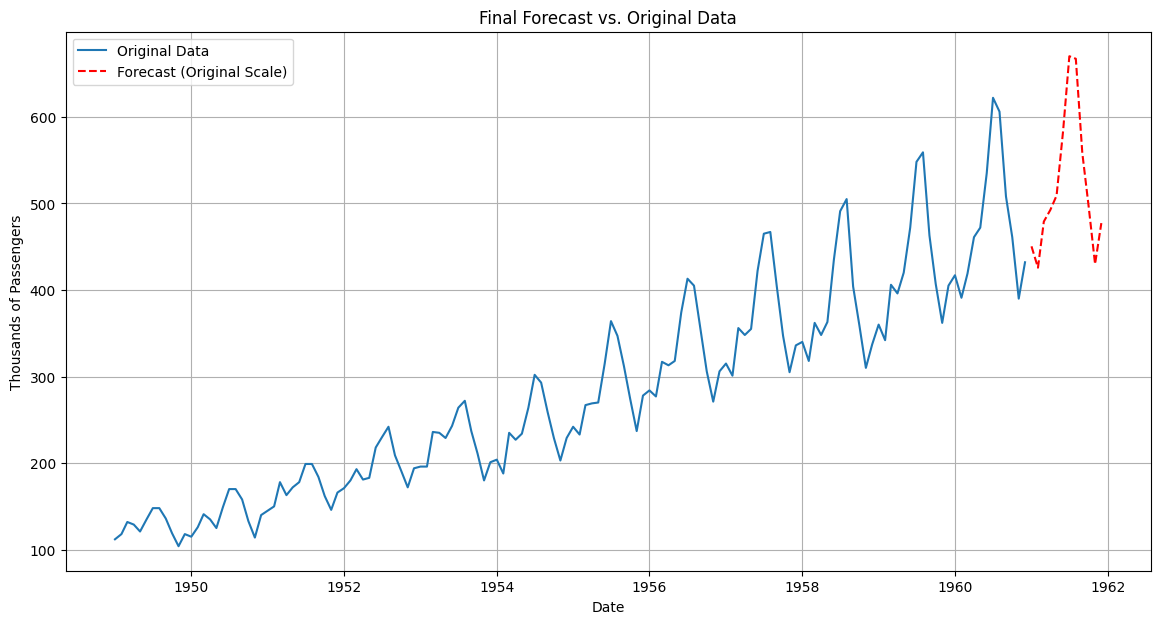

In [76]:
plt.figure(figsize=(14, 7))
plt.plot(df['Thousands of Passengers'], label='Original Data')
plt.plot(final_forecast_original_scale, label='Forecast (Original Scale)', linestyle='--', color='red')
plt.title('Final Forecast vs. Original Data')
plt.xlabel('Date')
plt.ylabel('Thousands of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Ensure actual_test_original is available; if not, re-create it
# In a real notebook, actual_test_original would already be defined if the previous plotting cell ran.
# For robustness, we can redefine it here if necessary.
if 'actual_test_original' not in globals():
    actual_test_original = df['Thousands of Passengers']['1960-01-01':]

rmse_original = np.sqrt(mean_squared_error(actual_test_original, final_forecast_original_scale))
mae_original = mean_absolute_error(actual_test_original, final_forecast_original_scale)
mape_original = mean_absolute_percentage_error(actual_test_original, final_forecast_original_scale)

print(f"RMSE on Original Scale: {rmse_original:.2f}")
print(f"MAE on Original Scale: {mae_original:.2f}")
print(f"MAPE on Original Scale: {mape_original:.2%}")


RMSE on Original Scale: 44.83
MAE on Original Scale: 43.80
MAPE on Original Scale: 9.26%


RMSE (Root Mean Squared Error) of 44.83: This indicates that, on average, the model's predictions for the Thousands of Passengers are off by approximately 44.83 passengers. Since RMSE penalizes larger errors more, this value also suggests the presence of some larger prediction deviations, which are now visible in the original scale.

MAE (Mean Absolute Error) of 43.80: This means that, on average, the model's predictions for the Thousands of Passengers deviate by about 43.80 passengers from the actual values. MAE is less sensitive to outliers than RMSE, so this value gives a good sense of the typical prediction error.

MAPE (Mean Absolute Percentage Error) of 9.26%: This is a very intuitive metric. It means that, on average, your forecast for Thousands of Passengers is off by approximately 9.26% relative to the actual passenger counts. A MAPE below 10% is generally considered very good in many forecasting contexts, suggesting that your model provides a reasonably accurate forecast for the airline passenger numbers.